In [1]:
import sys
from pathlib import Path

# point this at your repo root (folder that contains "src/")
repo_root = Path.cwd().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
    
import numpy as np
import matplotlib.pyplot as plt

## Step 1: Validate IGRF Models

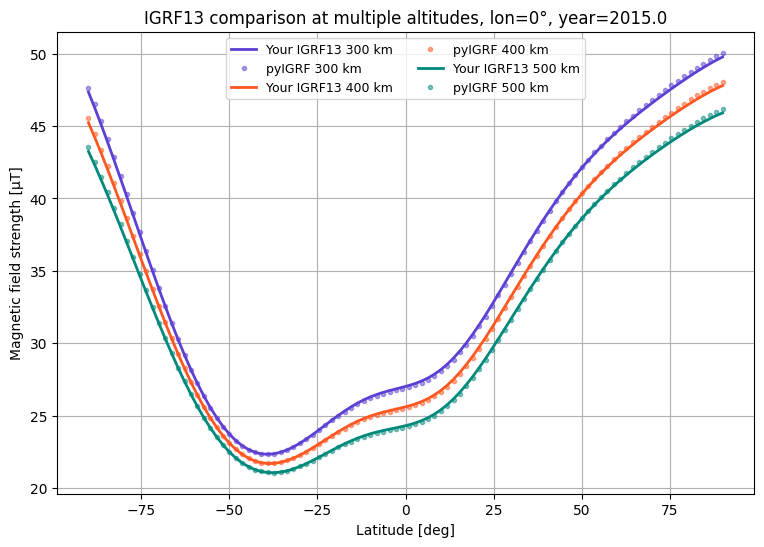

In [2]:
from darknessalp.bfield.IGRF13 import igrf13
from pyIGRF import igrf_value

year   = 2015.0
lon    = 0
lmax   = 13

# Avoid poles
eps = 1e-3
lats = np.linspace(-90+eps, 90-eps, 100)

alts = [300, 400, 500]  # km
colors = ['#5D3FD3', '#FF5722', '#00897B']  # iris, orange, teal

plt.figure(figsize=(9,6))

for alt_km, col in zip(alts, colors):
    Bmag_forms = []
    Bmag_ref   = []

    for lat in lats:
        # your IGRF13 implementation
        Bvec = igrf13(year, lat, lon, alt_km, lmax=lmax)
        Bmag_forms.append(np.linalg.norm(Bvec))

        # pyIGRF reference
        D, I, H, X, Y, Z, F = igrf_value(lat, lon, alt_km, year)
        Bmag_ref.append(F * 1e-9)

    Bmag_forms = np.array(Bmag_forms)
    Bmag_ref   = np.array(Bmag_ref)

    # plot both your model and reference
    plt.plot(lats, Bmag_forms*1e6, color=col, lw=2, label=f"Your IGRF13 {alt_km} km")
    plt.plot(lats, Bmag_ref*1e6, ".", color=col, alpha=0.5, label=f"pyIGRF {alt_km} km")

plt.xlabel("Latitude [deg]")
plt.ylabel("Magnetic field strength [µT]")
plt.title(f"IGRF13 comparison at multiple altitudes, lon={lon}°, year={year}")
plt.legend(ncol=2, fontsize=9)
plt.grid(True)
plt.show()


## Step 2: Suzaku Archival Obs
Suzaku’s X-ray Imaging Spectrometer (XIS) was actually a set of four CCD cameras:
XIS0 — front-illuminated (FI)
XIS1 — back-illuminated (BI)
XIS2 — FI (failed in 2006, not used later)
XIS3 — FI

In [2]:
repo_root = Path().resolve().parent  # from notebooks/, go up one
data_dir = repo_root / "data"
if str(data_dir) not in sys.path:
    sys.path.insert(0, str(data_dir))

from darknessalp.yamamoto.suzaku_archive import OBSIDS, load_orbit, load_attitude, load_event

obsid = OBSIDS["LockmanHole"][0]  # e.g., "101002010"
orbit = load_orbit(obsid)
att = load_attitude(obsid)
evt = load_event(obsid, xis=0)

print("Orbit columns:", orbit.keys())
print("Attitude columns:", att.keys())
print("Event shape:", evt["X"].shape, evt["Y"].shape)


Orbit columns: dict_keys(['EPOCH', 'A', 'E', 'I', 'AN', 'AP', 'MA', 'A.DOT', 'E.DOT', 'I.DOT', 'AN.DOT', 'AP.DOT', 'N', 'T', 'TIME', 'YYYYMMDD', 'HHMMSS'])
Attitude columns: dict_keys(['TIME', 'YYYYMMDD', 'HHMMSS', 'JD', 'EULER', 'DELTA', 'STATUS', 'ACP_RESI', 'IRU_DRIFT', 'IRU_DELTA', 'KALMAN_GAIN', 'STTA_RESI', 'STTB_RESI', 'NSAS_RESI', 'EULER_OLD', 'XOFFSET', 'YOFFSET', 'T_86', 'T_DY', 'FLAG_ATTCOR'])
Event shape: (16453,) (16453,)


## STEP 1: 
For Suzaku orbit and attitude handling we reimplemented the obs2xyz functionality in Python (using Astropy), since this utility is no longer distributed in modern HEASoft releases. For spectral fitting, RMF/ARF generation, and calibration, we used HEASoft v6.35 and XSPEC v12.16, while validating consistency against the original analysis pipeline (Yamamoto et al. 2014 used HEASoft v6.16 and XSPEC v12.8.2).

In [ ]:
# run_suzaku_pipeline_wsl.py
import subprocess, shlex, textwrap, os
from pathlib import Path
from darknessalp.yamamoto.suzaku_archive import download_event
import tempfile
# --- Configure your WSL HEASoft and CALDB paths ---
HEADAS = "/home/phi/heasoft-6.35.2/x86_64-pc-linux-gnu-libc2.39"
CALDB  = "/home/phi/caldb"  # adjust if different

# Windows-side repo root (with spaces handled). We’ll convert to /mnt/c/... for WSL.
WIN_REPO = Path(r"C:\Users\phial\Documents\Python\darkmatter")
WIN_DATA = WIN_REPO / "data" / "suzaku"

def win_to_wsl(p: Path) -> str:
    p = p.resolve()
    drive = str(p.drive).rstrip(":").lower()
    rest = str(p).split(":",1)[-1].replace("\\","/")
    return f"/mnt/{drive}{rest}"

def run_in_wsl(cmd: str) -> subprocess.CompletedProcess:
    inner = f"""
        set -e
        export HEADAS={shlex.quote(HEADAS)}
        export CALDB={shlex.quote(CALDB)}
        export CALDBCONFIG="$CALDB/software/tools/caldb.config"
        export CALDBALIAS="$CALDB/software/tools/alias_config.fits"
        source {shlex.quote(HEADAS)}/headas-init.sh
        {cmd}
    """
    return subprocess.run(
        ["wsl", "bash", "-lc", inner],
        text=True, check=False, capture_output=True   # no capture_output → stdout/stderr stream live
    )

def extract_spectrum(obsid: str, xis: int, evt_path_win: Path, outdir_win: Path,
                     region_exclude: Path|None=None):
    event_dir_win = evt_path_win.parent   # directory containing .evt
    event_dir_wsl = win_to_wsl(event_dir_win)
    outdir_wsl = win_to_wsl(outdir_win)

    outdir_win.mkdir(parents=True, exist_ok=True)

    # Build exact .xco script
    xco_lines = [
        "mysession",
        f"read event {evt_path_win.name}",
        "yes",
    ]
    if region_exclude:
        xco_lines.append(f"filter region {win_to_wsl(region_exclude)}")
    xco_lines += [
        "extract spectrum",
        f"save spectrum {outdir_wsl}/spec_unbinned.pha",
        "yes",   # answer the "Group/rebin?" prompt
        "exit",
        "no"     # answer the "Save this session?" prompt
    ]

    xco_text = "\n".join(xco_lines) + "\n"

    # Write it into work/
    xco_path = outdir_win / "extract.xco"
    xco_path.write_text(xco_text, encoding="utf-8")

    # Run xselect inside the event directory
    cmd = f"cd {event_dir_wsl} && xselect -nolog < {win_to_wsl(xco_path)}"
    result = run_in_wsl(cmd)

    # Verify product
    pha = outdir_win / "spec_unbinned.pha"
    if not pha.exists():
        print("STDOUT:\n", result.stdout)
        print("STDERR:\n", result.stderr)
        raise RuntimeError(f"xselect did not produce {pha}")

    return result


def make_nxb(outdir_win: Path, evt_dir_win: Path, obsid: str):
    """
    Generate NXB spectrum with xisnxbgen using a dummy full-chip region.
    This avoids CALDB lookup issues by providing an explicit detector region.
    """
    outdir_wsl = win_to_wsl(outdir_win)
    orbfile_win = WIN_DATA / obsid / f"ae{obsid}.orb"
    orbfile_wsl = win_to_wsl(orbfile_win)

    # Create dummy region file (DS9, physical coords = detector pixels)
    regfile_win = outdir_win / "fullchip.reg"
    regfile_win.write_text(
        "# Region file format: DS9 version 4.1\n"
        "physical\n"
        "box(512,512,1024,1024,0)\n",
        encoding="utf-8"
    )
    regfile_wsl = win_to_wsl(regfile_win)

    # Build xisnxbgen command
    cmd = (
        f'xisnxbgen '
        f'phafile="{outdir_wsl}/spec_unbinned.pha" '
        f'outfile="{outdir_wsl}/spec_nxb.pha" '
        f'orbit="{orbfile_wsl}" '
        f'regfile="{regfile_wsl}" region_mode=DETREG '
        f'attitude=NONE '
        f'clobber=yes chatter=5'
    )

    return run_in_wsl(cmd)

def rebin_nxb(outdir_win: Path, nchan=2048):
    outdir_wsl = win_to_wsl(outdir_win)
    infile = f"{outdir_wsl}/spec_nxb.pha"
    outfile = f"{outdir_wsl}/spec_nxb_{nchan}.pha"

    cmd = (
        f'rbnpha infile="{infile}" outfile="{outfile}" '
        f'finchan={nchan} cmpmode=linear error=poiss-0 properr=no '
        f'clobber=yes'
    )
    result = run_in_wsl(cmd)

    out_pha = outdir_win / f"spec_nxb_{nchan}.pha"
    if not out_pha.exists():
        raise RuntimeError(f"rbnpha failed to produce {out_pha}")

    return result

def make_rmf(outdir_win: Path):
    """Generate RMF with xisrmfgen (non-interactive)."""
    outdir_wsl = win_to_wsl(outdir_win)
    cmd = (
        f'xisrmfgen '
        f'phafile="{outdir_wsl}/spec_unbinned.pha" '
        f'outfile="{outdir_wsl}/resp.rmf" '
        f'clobber=yes chatter=5'
    )
    return run_in_wsl(cmd)


def make_arf(xis: int, outdir_win: Path, num_photon=200_000):
    """Generate ARF for diffuse emission via xissimarfgen (non-interactive)."""
    outdir_wsl = win_to_wsl(outdir_win)
    cmd = (
        f'xissimarfgen '
        f'instrume=XIS{xis} '
        f'source_mode=UNIFORM '
        f'source_rmin=0.0 source_rmax=20.0 '
        f'region_mode=UNIFORM '
        f'num_region=1 '
        f'regfile1=none '
        f'arffile1="{outdir_wsl}/resp.arf" '
        f'phafile="{outdir_wsl}/spec_unbinned.pha" '
        f'rmffile="{outdir_wsl}/resp.rmf" '
        f'num_photon={num_photon} '
        f'limit_mode=MIXED '
        f'clobber=yes chatter=5'
    )
    return run_in_wsl(cmd)


def write_min_xspec_script(outdir_win: Path, xis: int, use_range_xis1=False):
    is_xis1 = (xis == 1) and use_range_xis1
    rng = "**-0.7 " + ("5.0-**" if is_xis1 else "7.0-**")
    outdir_wsl = win_to_wsl(outdir_win)

    xcm = f"""\
    statistic cstat
    abund angr
    xsect vern

    data 1: {outdir_wsl}/spec_unbinned.pha
    back 1: {outdir_wsl}/spec_nxb_2048.pha
    resp 1: {outdir_wsl}/resp.rmf
    arf  1: {outdir_wsl}/resp.arf

    ignore {rng}

    # XDB baseline model
    model  apec + phabs*(apec + powerlaw + apec)

    fit
    """
    (outdir_win / "fit_min.xcm").write_text(xcm, encoding="utf-8")


def run_xspec(outdir_win: Path, xcm_name="fit_min.xcm"):
    script_wsl = win_to_wsl(outdir_win / xcm_name)
    cmd = f'xspec - {script_wsl}'
    return run_in_wsl(cmd)

def run_pipeline_single(obsid: str, xis: int,
                        evt_guess_name="ae{obs}xi{xis}_0_3x3n000d_cl.evt",
                        region_exclude: Path | None = None):
    """
    Run steps 2–4–6 for a single ObsID/CCD on the cleaned event.
    Auto-discovers the actual filename; downloads via suzaku_archive if missing.
    """
    # 1) Try the guessed name
    base = WIN_DATA / obsid / f"xis{xis}"
    base.mkdir(parents=True, exist_ok=True)
    evt = base / evt_guess_name.format(obs=obsid, xis=xis)

    # 2) If not there, try to find any cleaned event locally (3x3/5x5, any rev), preferring 3x3
    if not evt.exists():
        candidates = list(base.glob(f"ae{obsid}xi{xis}*_cl.evt")) + list(
            base.glob(f"ae{obsid}xi{xis}*_cl.evt.gz"))
        if candidates:
            # prefer 3x3 over 5x5; prefer uncompressed over .gz
            def score(p: Path):
                name = p.name
                mode_rank = 0 if "3x3" in name else 1
                gz_rank = 1 if name.endswith(".gz") else 0
                return (mode_rank, gz_rank, name)

            candidates.sort(key=score)
            evt = candidates[0]
        else:
            # 3) Not on disk — fetch from HEASARC via your module (returns unzipped .evt)
            print(f"[download] fetching cleaned event for ObsID {obsid} XIS{xis} via suzaku_archive...")
            evt_path = download_event(obsid, xis=xis, basedir=Path(WIN_DATA))
            evt = Path(evt_path)  # should be uncompressed .evt

    # 4) If gzipped, unzip to .evt alongside
    if evt.suffix == ".gz":
        import gzip, shutil
        target = evt.with_suffix("")  # drop .gz
        if not target.exists():
            with gzip.open(evt, "rb") as fin, open(target, "wb") as fout:
                shutil.copyfileobj(fin, fout)
        evt = target

    if not evt.exists():
        raise FileNotFoundError(
            f"Could not locate or download a cleaned event for ObsID={obsid} XIS={xis}"
        )

    outdir = WIN_DATA / obsid / f"xis{xis}" / "work"
    outdir.mkdir(parents=True, exist_ok=True)

    print(f"[xselect] {obsid} XIS{xis} — using {evt.name}")
    r1 = timed_step("xselect", extract_spectrum, obsid, xis, evt, outdir,
                    region_exclude=region_exclude)
    print(r1.stdout)
    print(r1.stderr)

    # evt.parent is the directory where the .evt lives (…/xis0)
    r2 = timed_step("xisnxbgen", make_nxb, outdir, evt.parent, obsid)
    print(r2.stdout); print(r2.stderr)

    r2b = timed_step("rbnpha", rebin_nxb, outdir, 2048)
    print(r2b.stdout)
    print(r2b.stderr)


    r3 = timed_step("xisrmfgen", make_rmf, outdir)
    print(r3.stdout)
    print(r3.stderr)

    r4 = timed_step("xissimarfgen", make_arf, xis, outdir)
    print(r4.stdout)
    print(r4.stderr)

    print("[XSPEC] minimal XDB fit")
    write_min_xspec_script(outdir, xis, use_range_xis1=True)
    r5 = timed_step("xspec", run_xspec, outdir)
    print(r5.stdout)
    print(r5.stderr)


import time

def timed_step(label, func, *args, **kwargs):
    print(f"[{label}] starting...")
    t0 = time.time()
    result = func(*args, **kwargs)
    t1 = time.time()
    print(f"[{label}] finished in {t1 - t0:.1f} s")

    # Write stdout/stderr to log file
    log_path = Path(args[0]) / f"{label}.log" if isinstance(args[0], Path) else None
    if log_path:
        with open(log_path, "w", encoding="utf-8") as f:
            f.write(result.stdout or "")
            f.write(result.stderr or "")

    # Also echo first few lines so you know what happened
    if result.stdout:
        print(result.stdout.splitlines()[:10])  # first 10 lines
    if result.stderr:
        print("STDERR:", result.stderr.strip())

    return result

if __name__ == "__main__":
    # Example: Lockman Hole first ObsID, XIS0
    run_pipeline_single(obsid="101002010", xis=0)

[xselect] 101002010 XIS0 — using ae101002010xi0_0_3x3n000a_cl.evt
[xselect] starting...
[xselect] finished in 1.2 s
[' ', '                         **  XSELECT V2.5c  **', ' ', '> Enter session name >[mysession] mysession', 'mysession:XRISM > ', 'mysession:XRISM > read event ae101002010xi0_0_3x3n000a_cl.evt', '> Enter the Event file dir >[./] ', 'Got new mission: SUZAKU', '> Reset the mission ? >[yes] yes', ' ']
 
                         **  XSELECT V2.5c  **
 
> Enter session name >[mysession] mysession
mysession:XRISM > 
mysession:XRISM > read event ae101002010xi0_0_3x3n000a_cl.evt
> Enter the Event file dir >[./] 
Got new mission: SUZAKU
> Reset the mission ? >[yes] yes
 
 
        OBJECT       DATE-OBS            DATE-END            EDITMODE
      1 LOCKMAN HOLE 2006-05-17T17:44:06 2006-05-19T19:03:18 3x3
 
 Notes: XSELECT set up for      SUZAKU
 Time keyword is TIME       in units of s
 Default timing binsize =   16.000
 
Setting...
 Image  keywords   = X          Y           wit